# CTG (Fetal cardiotocography) Dataset – Exploratory Data Analysis (EDA)

Focus:
- Feature distributions
- Missing (null) values



## 1. Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

real_path = 'Real_Datasets/CTG_cleaned.csv'
df = pd.read_csv(real_path)

print('Dataset shape:', df.shape)
df.head()

Dataset shape: (2126, 38)


,SegFile,b,e,LBE,LB,AC,FM,UC,ASTV,MSTV,...,C,D,E,AD,DE,LD,FS,SUSP,CLASS,NSP
0,CTG0001.txt,240.0,357.0,120.0,120.0,0.0,0.0,0.0,73.0,0.5,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,9.0,2.0
1,CTG0002.txt,5.0,632.0,132.0,132.0,4.0,0.0,4.0,17.0,2.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
2,CTG0003.txt,177.0,779.0,133.0,133.0,2.0,0.0,5.0,16.0,2.1,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
3,CTG0004.txt,411.0,1192.0,134.0,134.0,2.0,0.0,6.0,16.0,2.4,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,6.0,1.0
4,CTG0005.txt,533.0,1147.0,132.0,132.0,4.0,0.0,5.0,16.0,2.4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0


## 2. Data Types

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   SegFile   2126 non-null   object 
 1   b         2126 non-null   float64
 2   e         2126 non-null   float64
 3   LBE       2126 non-null   float64
 4   LB        2126 non-null   float64
 5   AC        2126 non-null   float64
 6   FM        2126 non-null   float64
 7   UC        2126 non-null   float64
 8   ASTV      2126 non-null   float64
 9   MSTV      2126 non-null   float64
 10  ALTV      2126 non-null   float64
 11  MLTV      2126 non-null   float64
 12  DL        2126 non-null   float64
 13  DS        2126 non-null   float64
 14  DP        2126 non-null   float64
 15  DR        2126 non-null   float64
 16  Width     2126 non-null   float64
 17  Min       2126 non-null   float64
 18  Max       2126 non-null   float64
 19  Nmax      2126 non-null   float64
 20  Nzeros    2126 non-null   floa

## 3. Missing Values

In [3]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_abs,
    'missing_percent': missing_pct
})

total_cells = df.shape[0] * df.shape[1]
total_missing = df.isna().sum().sum()

missing_percentage = (total_missing / total_cells) * 100
print("total missing values:", missing_percentage)

missing_df[missing_df.missing_count > 0].head(20)

total missing values: 0.0


,missing_count,missing_percent


## 4. Missing Values Plot

In [4]:
if missing_pct[missing_pct > 0].size == 0:
    print("no missing values to plot")
else:
    print(missing_pct[missing_pct > 0].size)
    plt.figure(figsize=(10,5))
    missing_pct[missing_pct > 0].plot(kind='bar')
    plt.ylabel('Missing (%)')
    plt.title('Missing Values per Column')
    plt.tight_layout()
    plt.show()

no missing values to plot


In [5]:
df_filtered = df[df.isna().sum(axis=1) <= 1]
print("Original shape:", df.shape)
print("Filtered shape:", df_filtered.shape)

print("Rows removed:", df.shape[0] - df_filtered.shape[0])

x = 30  # threshold in percent

missing_pct = df_filtered.isna().mean() * 100
df_filtered2 = df_filtered.loc[:, missing_pct <= x]
#df_filtered2 = df_filtered.drop(df_filtered.columns[[0]], axis=1)

removed = set(df_filtered.columns) - set(df_filtered2.columns)
print("Dropped columns:", removed)

print("Filtered2 shape:", df_filtered2.shape)

#df_filtered2.to_csv('Real_Datasets/CTG_cleaned.csv',index=False)

Original shape: (2126, 38)
Filtered shape: (2126, 38)
Rows removed: 0
Dropped columns: set()
Filtered2 shape: (2126, 38)


In [6]:
print(f"\n{'='*60}")
print(f"NaN overview:")
print(f"{'='*60}")

total_rows = len(df)

# Replace inf with NaN so we catch those too
df = df.replace([np.inf, -np.inf], np.nan)

# Column-wise NaN count
nan_counts = df.isna().sum()
nan_percent = (nan_counts / total_rows * 100).round(2)

summary = pd.DataFrame({
    "NaN Count": nan_counts,
    "NaN %": nan_percent
}).sort_values("NaN Count", ascending=False)

print("\nColumn-wise NaN summary:")
display(summary[summary["NaN Count"] > 0])

# Row-level info
rows_with_nan = df.isna().any(axis=1).sum()
print(f"\nTotal rows: {total_rows}")
print(f"Rows containing at least one NaN: {rows_with_nan}")
print(f"Percentage of rows with NaN: {(rows_with_nan/total_rows*100):.2f}%")

# Show example problematic rows
if rows_with_nan > 0:
    print("\nExample rows with NaNs:")
    display(df[df.isna().any(axis=1)].head())

print(summary)




NaN overview:

Column-wise NaN summary:


,NaN Count,NaN %



Total rows: 2126
Rows containing at least one NaN: 0
Percentage of rows with NaN: 0.00%
          NaN Count  NaN %
SegFile           0    0.0
C                 0    0.0
Mode              0    0.0
Mean              0    0.0
Median            0    0.0
Variance          0    0.0
Tendency          0    0.0
A                 0    0.0
B                 0    0.0
D                 0    0.0
b                 0    0.0
E                 0    0.0
AD                0    0.0
DE                0    0.0
LD                0    0.0
FS                0    0.0
SUSP              0    0.0
CLASS             0    0.0
Nzeros            0    0.0
Nmax              0    0.0
Max               0    0.0
Min               0    0.0
e                 0    0.0
LBE               0    0.0
LB                0    0.0
AC                0    0.0
FM                0    0.0
UC                0    0.0
ASTV              0    0.0
MSTV              0    0.0
ALTV              0    0.0
MLTV              0    0.0
DL                0 

## 5. Numeric Distributions

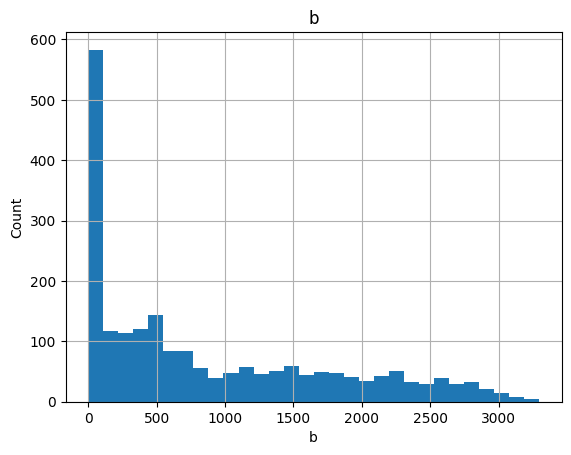

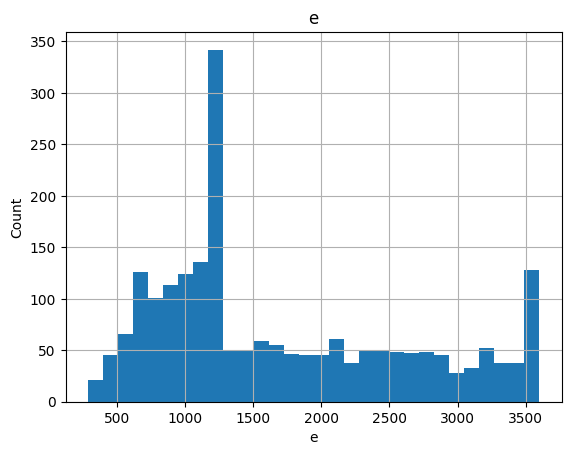

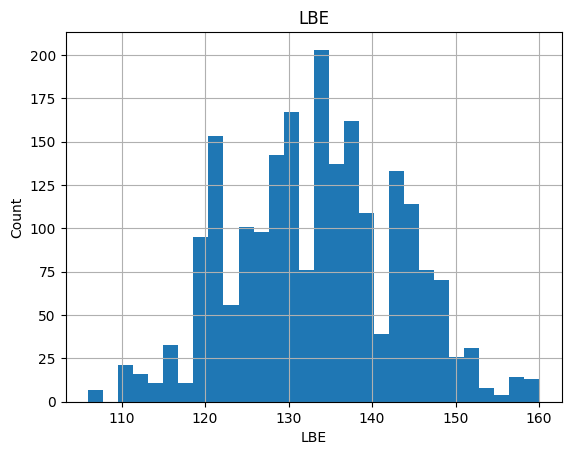

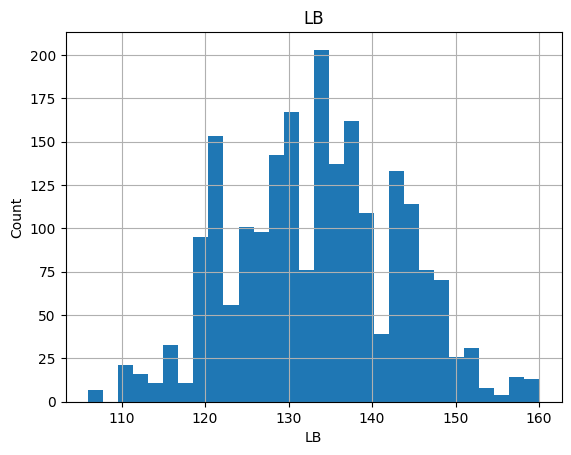

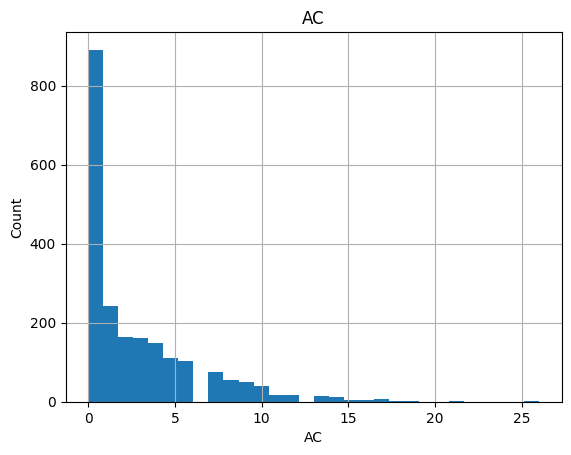

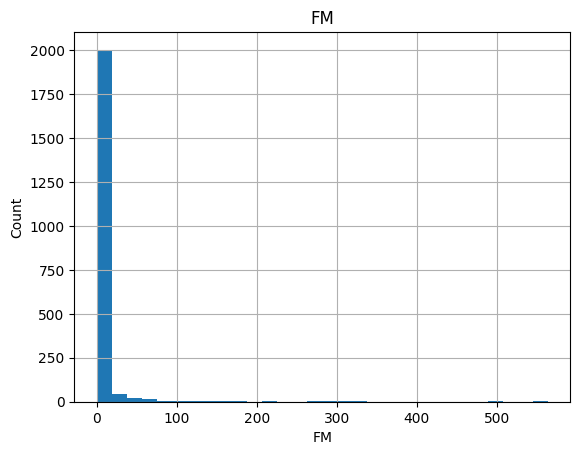

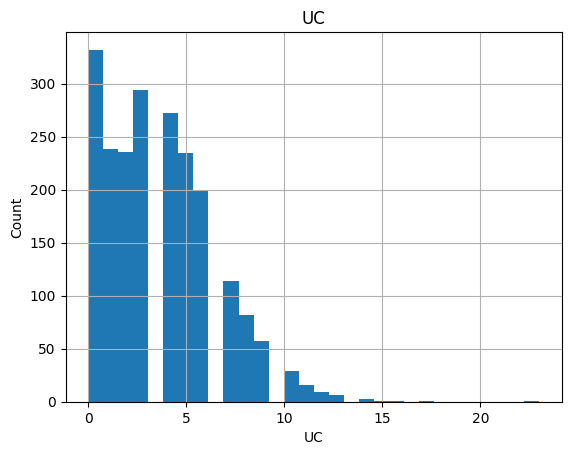

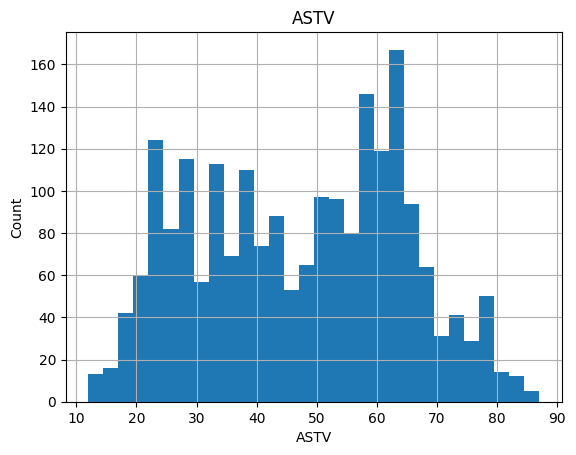

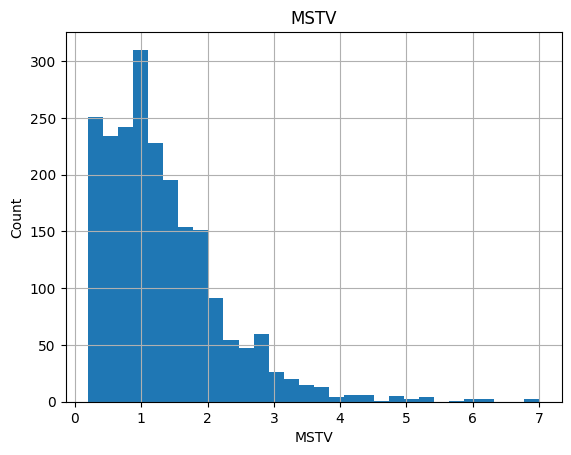

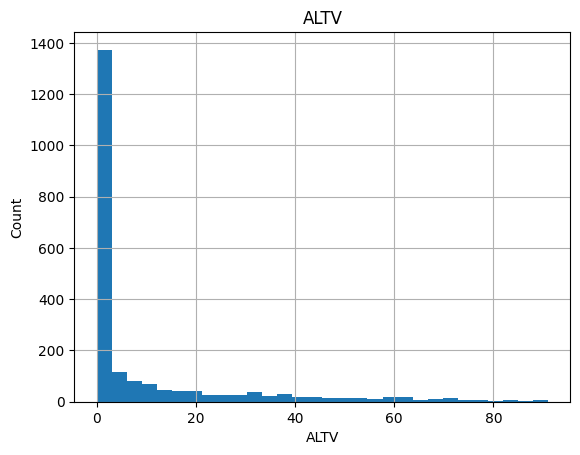

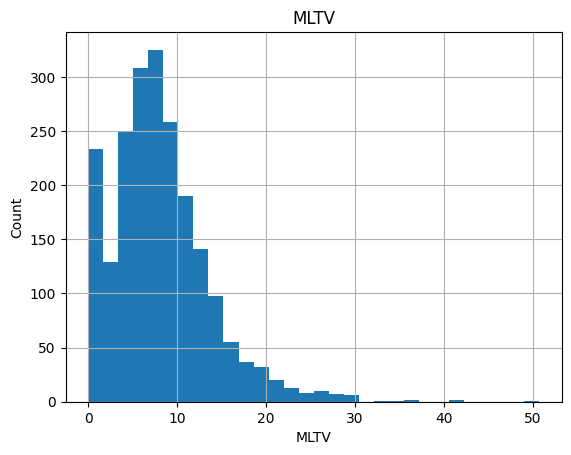

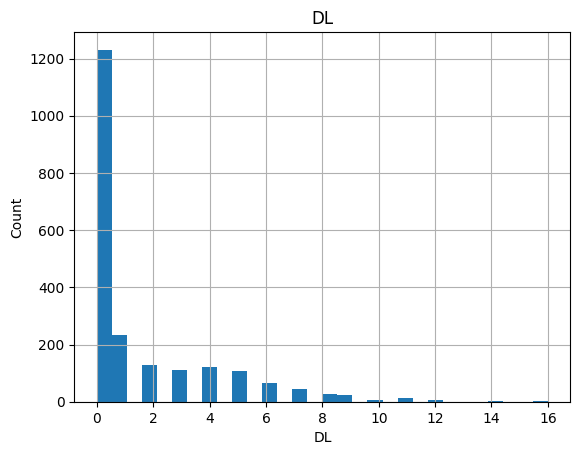

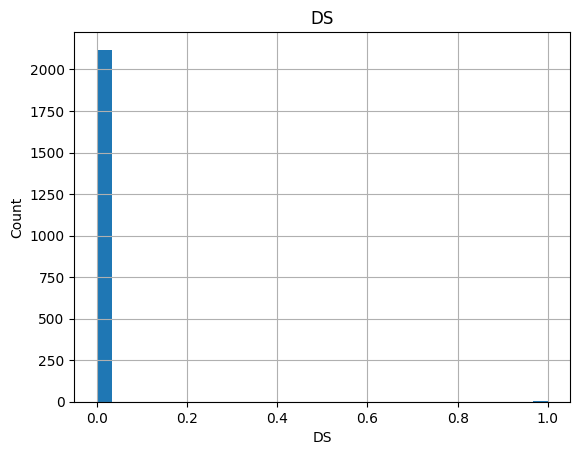

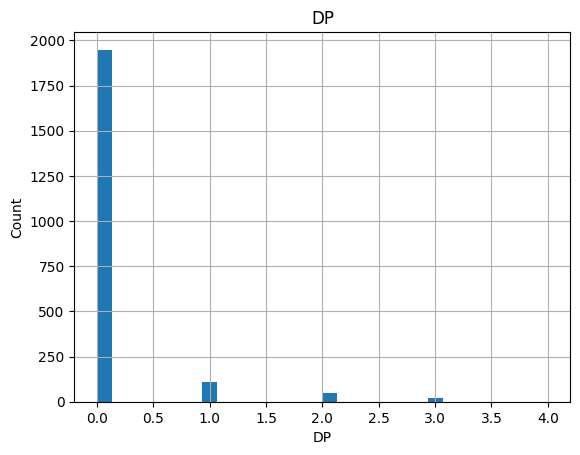

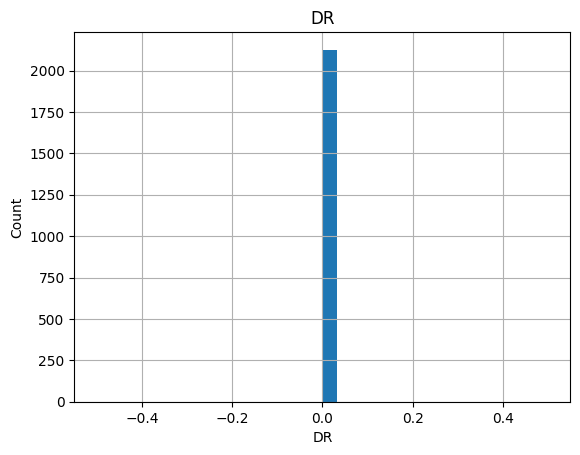

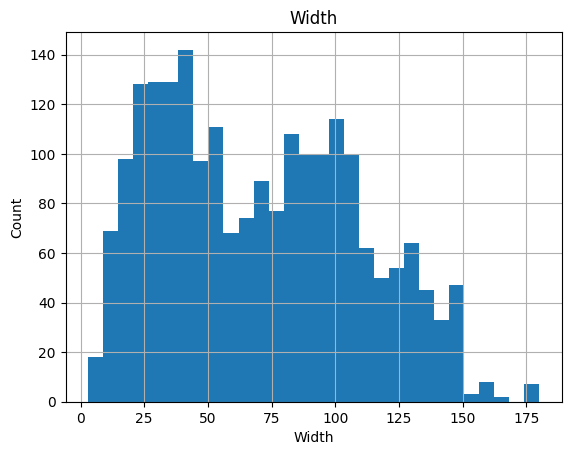

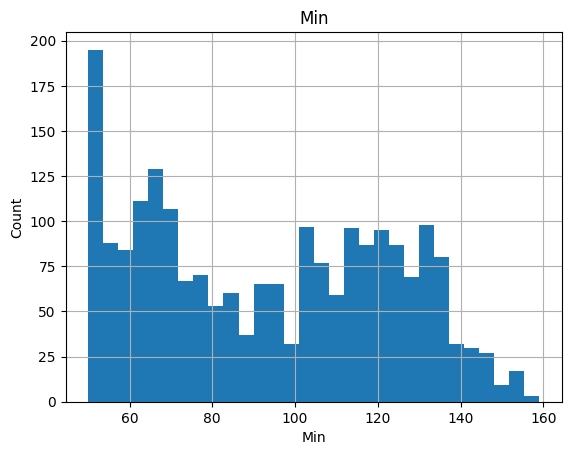

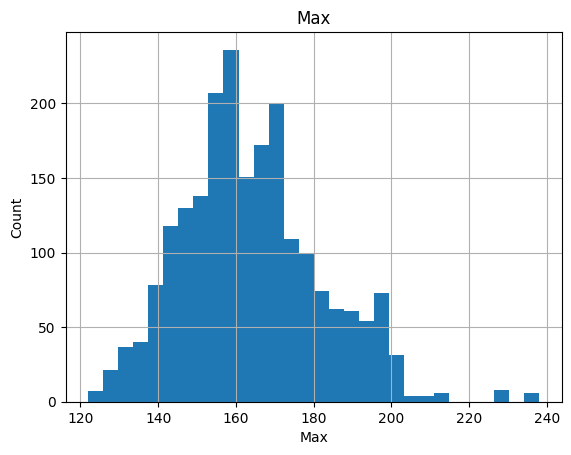

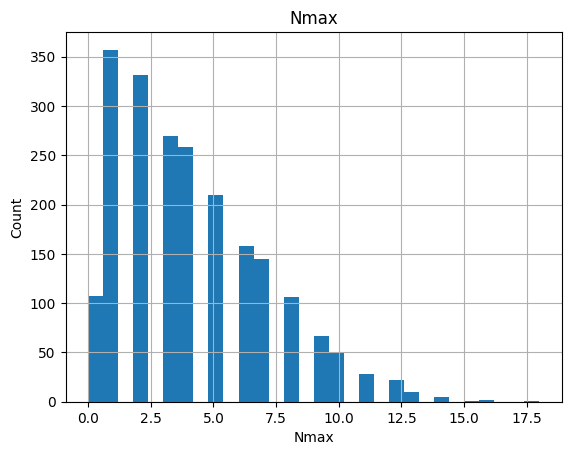

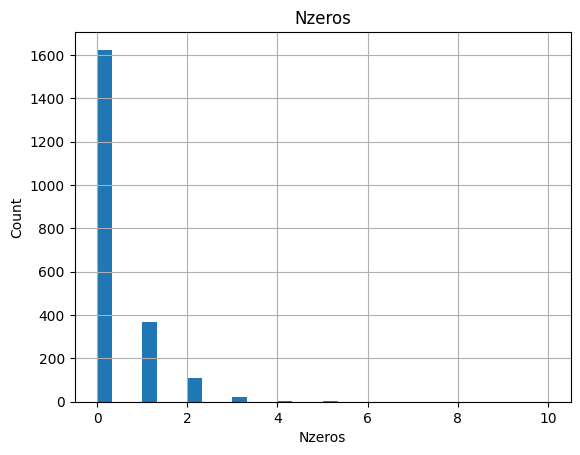

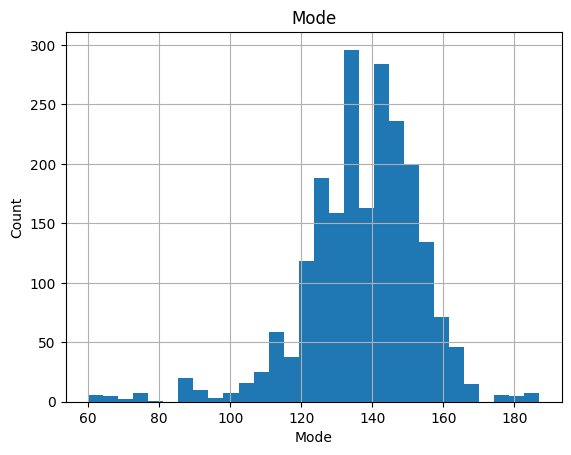

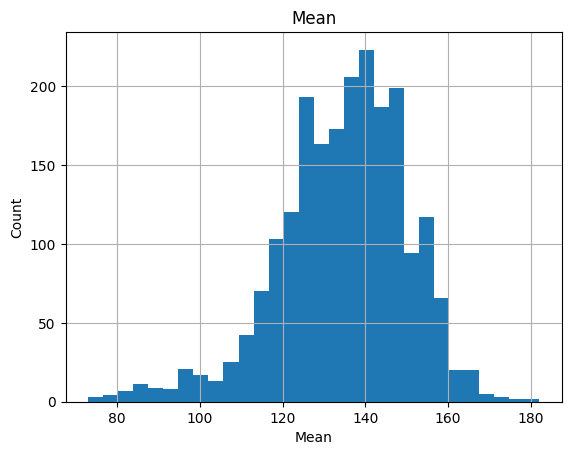

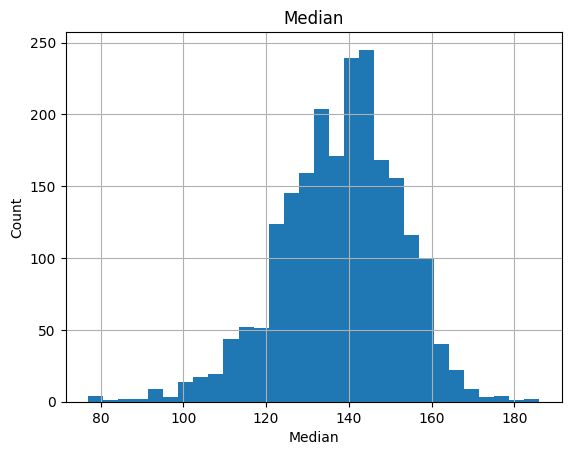

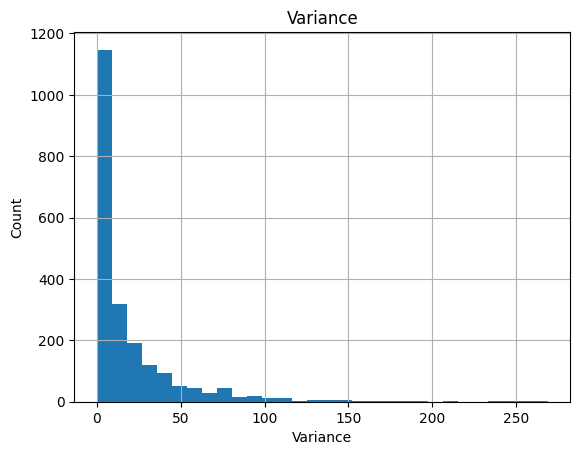

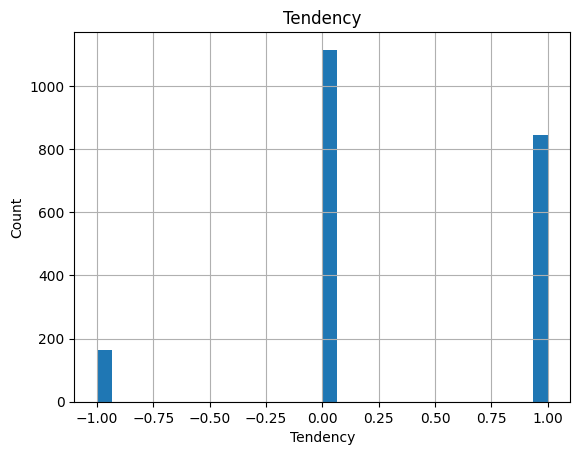

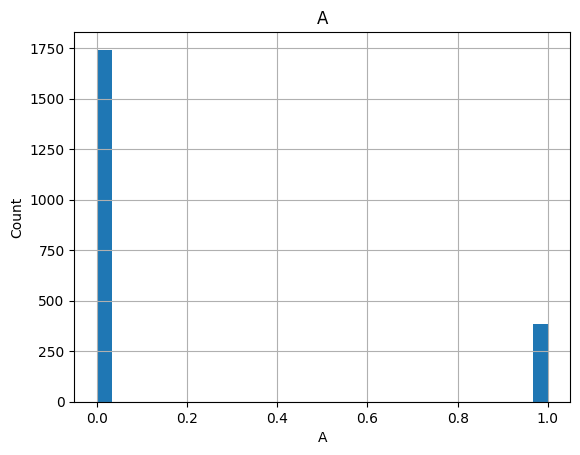

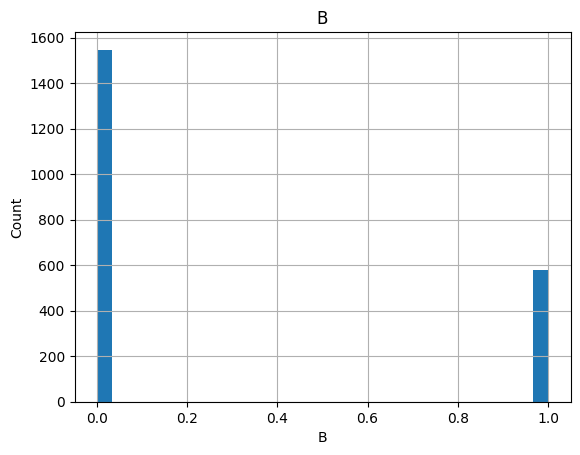

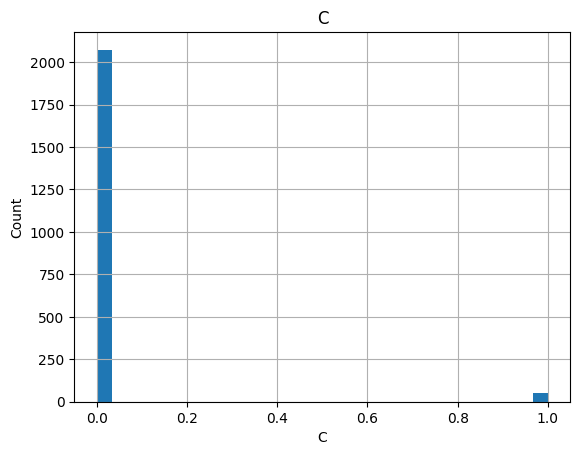

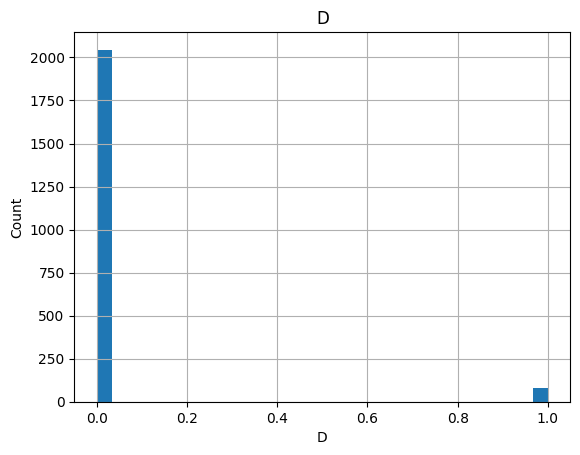

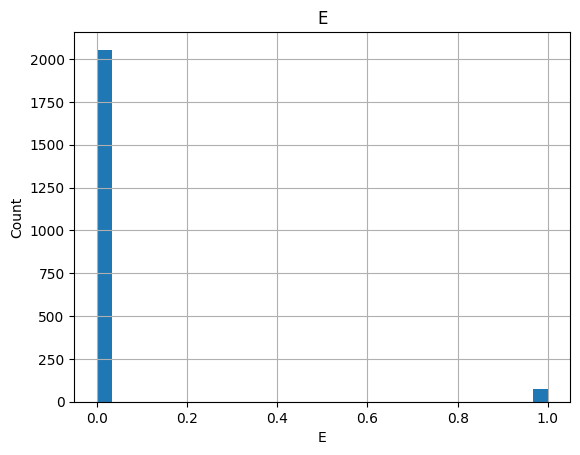

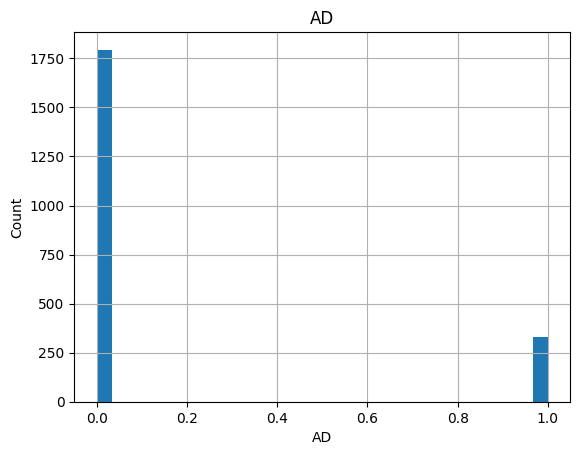

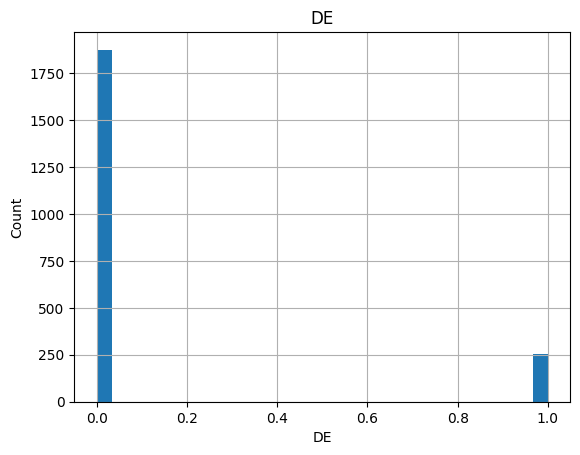

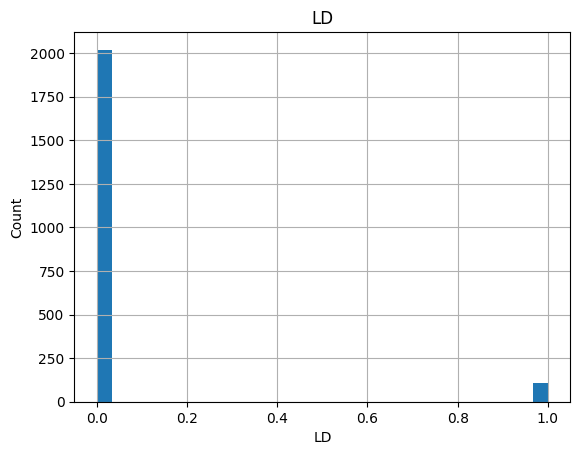

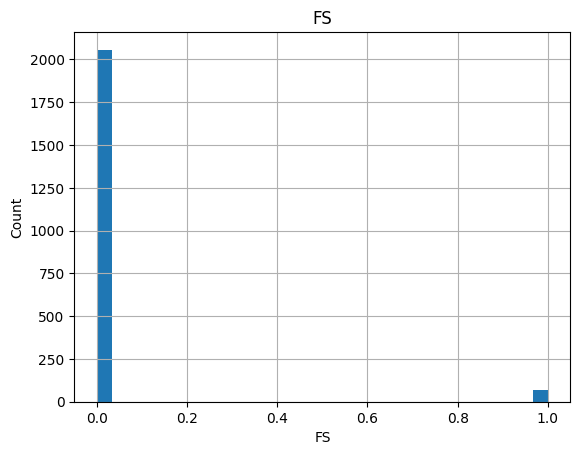

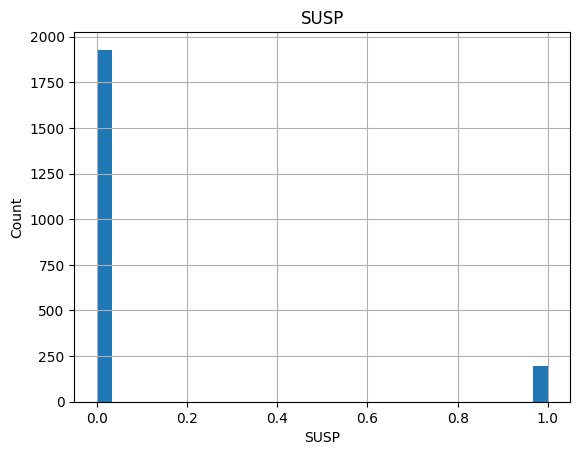

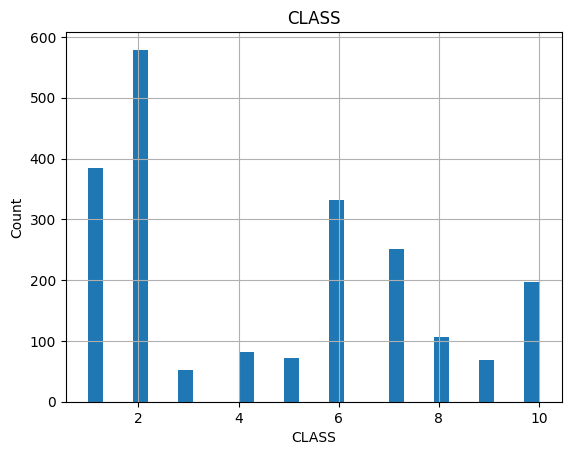

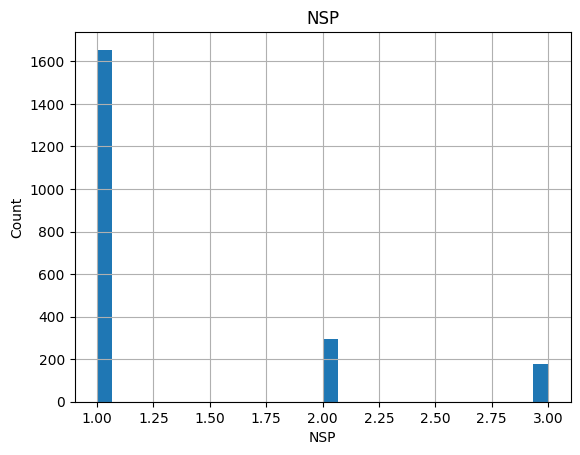

In [7]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    plt.figure()
    df[col].dropna().hist(bins=30)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

## 6. Categorical Distributions

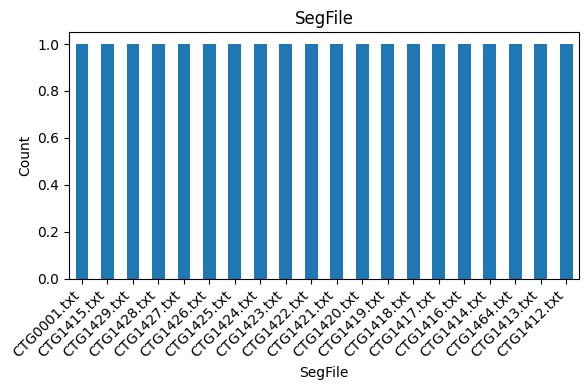

In [8]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).head(20).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## 7. Notes
- Columns with high missingness may need imputation or removal
- Highly skewed distributions may require transformation before GAN training